# EDA: Анализ данных системы предиктивного обслуживания роботов

Исследовательский анализ трёх **Silver**-таблиц:

| Таблица | Источник | Записей |
|---|---|---|
| `maintenance_events` | синтетик (Bitrix-совместимая схема) | 93 |
| `task_reports` | Gausium API | 11 095 |
| `robot_status` | Gausium API (опрос каждые 15 мин) | 149 868 |

**Период:** 2025-11-02 — 2026-05-01 · **Флот:** 12 роботов · **Длительность:** 181 день

In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 110, 'figure.figsize': (14, 5)})

SILVER = 'data/silver'
con = duckdb.connect()

maint = con.execute(
    f"SELECT * FROM read_parquet('{SILVER}/maintenance_events/dt=*/*.parquet') ORDER BY completed_at"
).df()

tasks = con.execute(
    f"SELECT * FROM read_parquet('{SILVER}/task_reports/dt=*/*.parquet') ORDER BY start_time"
).df()

status = con.execute(f"""
    SELECT serial_number, poll_ts, task_state, battery_soc, battery_charging,
           battery_health, battery_cycle_times, battery_temp1, battery_temp2,
           rolling_brush_used_life_h, soft_squeegee_used_life_h,
           clean_water_filter_used_life_h, hepa_sensor_used_life_h,
           clean_water_tank_pct, recovery_water_tank_pct, speed_kmh, dt
    FROM read_parquet('{SILVER}/robot_status/dt=*/*.parquet')
    ORDER BY poll_ts
""").df()

# Короткое имя робота (последние 4 символа серийника)
def short_id(serial): return serial.split('-')[-1]

tasks['robot_id']  = tasks['robot_serial_number'].apply(short_id)
status['robot_id'] = status['serial_number'].apply(short_id)
maint['robot_id']  = maint['robot_id_full'] = maint['robot_id']
maint['robot_id']  = maint['robot_id_full'].apply(short_id)

print(f'maintenance_events : {len(maint):>7,} records')
print(f'task_reports       : {len(tasks):>7,} records')
print(f'robot_status       : {len(status):>7,} records')
print(f'Period             : {tasks.start_time.min().date()} — {tasks.start_time.max().date()}')

maintenance_events :      93 records
task_reports       :  11,095 records
robot_status       : 149,868 records
Period             : 2025-11-02 — 2026-05-02


---
## 1. Обзор данных

In [2]:
# Сводка по роботам
summary = tasks.groupby('robot_serial_number').agg(
    missions      = ('report_id',              'count'),
    area_m2       = ('actual_area_m2',         'sum'),
    avg_compl_pct = ('completion_percentage',  'mean'),
    avg_batt_drop = ('battery_delta_pct',      'mean'),
).reset_index()
summary['area_km2']       = (summary['area_m2'] / 1e6).round(3)
summary['avg_compl_pct']  = (summary['avg_compl_pct'] * 100).round(1)
summary['avg_batt_drop']  = summary['avg_batt_drop'].round(1)
summary['model']          = summary['robot_serial_number'].apply(
    lambda s: 'W50H' if s.startswith('CB300') else 'W1')

display(summary[['robot_serial_number', 'model', 'missions', 'area_km2',
                  'avg_compl_pct', 'avg_batt_drop']]
        .rename(columns={
            'robot_serial_number': 'serial',
            'area_km2':            'area cleaned, km²',
            'avg_compl_pct':       'avg completion, %',
            'avg_batt_drop':       'avg battery Δ, %',
        })
        .sort_values('missions', ascending=False)
        .reset_index(drop=True))

,serial,model,missions,"area cleaned, km²","avg completion, %","avg battery Δ, %"
0,CB500-2100-W1R-0005,W1,1281,0.592,57.8,-0.0
1,CB500-2100-W1R-0007,W1,1227,0.539,60.5,0.0
2,CB300-2200-W5R-0001,W50H,1204,0.657,60.9,-0.0
3,CB500-2100-W1R-0001,W1,1116,0.200,68.8,-0.0
4,CB300-2200-W5R-0002,W50H,1057,0.509,60.1,-0.0
5,CB500-2100-W1R-0009,W1,976,0.324,66.3,0.0
6,CB500-2100-W1R-0006,W1,969,0.341,64.0,-0.1
7,CB500-2100-W1R-0004,W1,808,0.224,72.1,-0.0
8,CB500-2100-W1R-0010,W1,788,0.225,68.2,-0.0
9,CB500-2100-W1R-0002,W1,763,0.190,73.3,-0.0


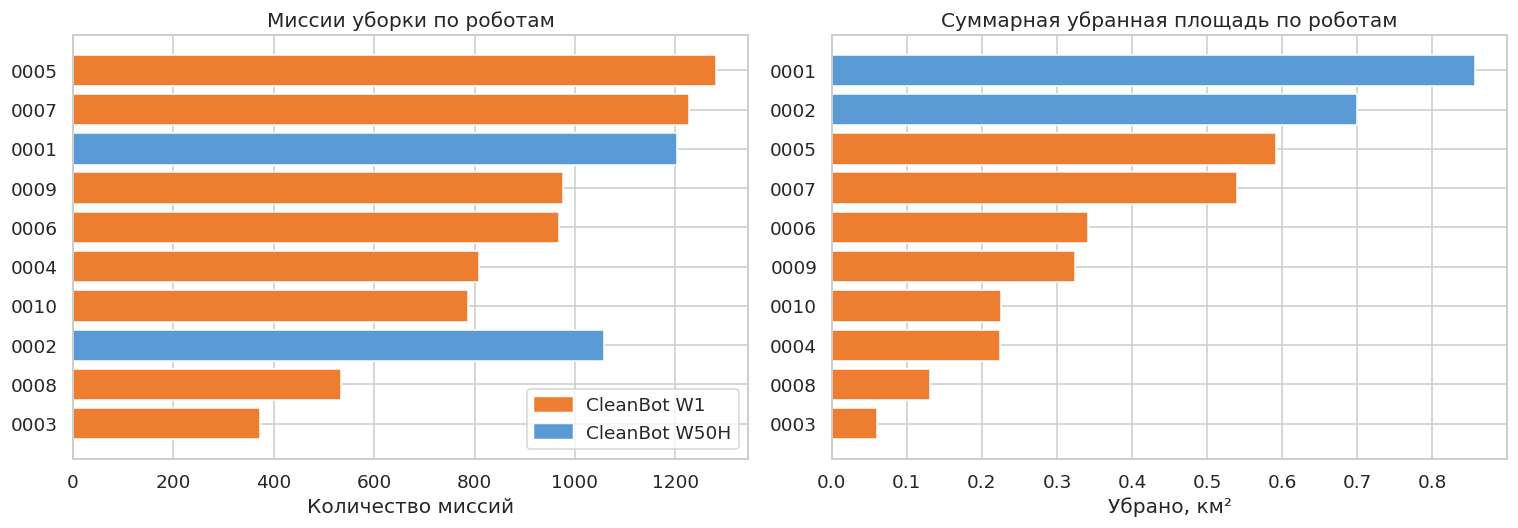

In [3]:
# Активность флота: количество миссий и суммарная площадь по роботам
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

robot_missions = (tasks.groupby(['robot_id', 'robot_serial_number'])
                  .size().reset_index(name='missions')
                  .sort_values('missions', ascending=True))
colors = ['#5B9BD5' if s.startswith('CB300') else '#ED7D31'
          for s in robot_missions['robot_serial_number']]

axes[0].barh(robot_missions['robot_id'], robot_missions['missions'], color=colors)
axes[0].set_xlabel('Количество миссий')
axes[0].set_title('Миссии уборки по роботам')
from matplotlib.patches import Patch
axes[0].legend(handles=[Patch(color='#ED7D31', label='CleanBot W1'),
                         Patch(color='#5B9BD5', label='CleanBot W50H')], loc='lower right')

area_by_robot = (tasks.groupby('robot_id')['actual_area_m2'].sum() / 1e6).sort_values()
axes[1].barh(area_by_robot.index, area_by_robot.values,
             color=['#5B9BD5' if i in ('0001', '0002')  # W50H
                    else '#ED7D31' for i in area_by_robot.index])
axes[1].set_xlabel('Убрано, км²')
axes[1].set_title('Суммарная убранная площадь по роботам')

plt.tight_layout()
plt.show()

---
## 2. Техническое обслуживание

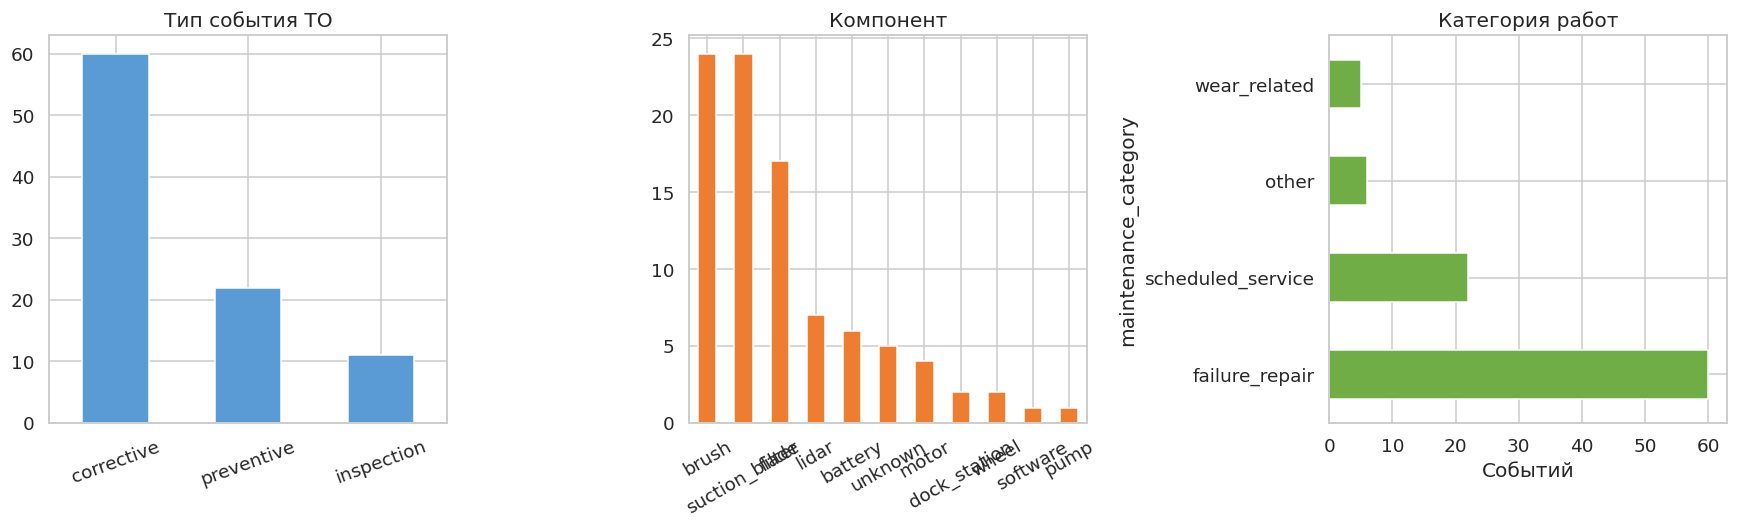


Событий всего: 93
Подтверждённых отказов: 60 (65%)


In [4]:
# Распределение событий ТО по типу, категории и компоненту
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

maint['maintenance_type'].value_counts().plot.bar(ax=axes[0], color='#5B9BD5', edgecolor='white')
axes[0].set_title('Тип события ТО')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=20)

maint['component'].value_counts().plot.bar(ax=axes[1], color='#ED7D31', edgecolor='white')
axes[1].set_title('Компонент')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)

maint['maintenance_category'].value_counts().plot.barh(ax=axes[2], color='#70AD47', edgecolor='white')
axes[2].set_title('Категория работ')
axes[2].set_xlabel('Событий')

plt.tight_layout()
plt.show()

print(f"\nСобытий всего: {len(maint)}")
print(f"Подтверждённых отказов: {maint['failure_detected'].sum()} "
      f"({maint['failure_detected'].mean()*100:.0f}%)")

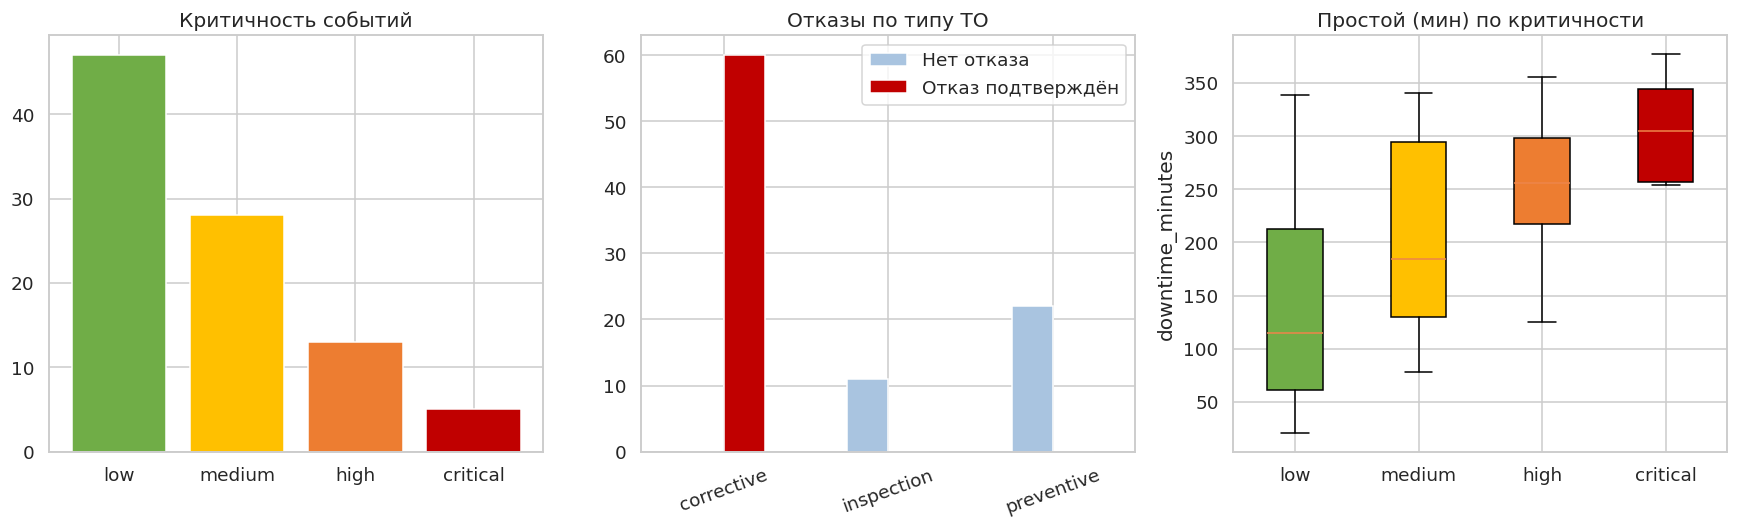

In [5]:
# Критичность, отказы и простой
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Severity
sev_order = ['low', 'medium', 'high', 'critical']
sev_colors = ['#70AD47', '#FFC000', '#ED7D31', '#C00000']
sev_counts = maint['severity'].value_counts().reindex(sev_order, fill_value=0)
axes[0].bar(sev_counts.index, sev_counts.values, color=sev_colors, edgecolor='white')
axes[0].set_title('Критичность событий')
axes[0].set_xlabel('')

# Failure detected by type
fail = maint.groupby(['maintenance_type', 'failure_detected']).size().unstack(fill_value=0)
fail.plot.bar(ax=axes[1], color=['#A9C4E0', '#C00000'], edgecolor='white')
axes[1].set_title('Отказы по типу ТО')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend(['Нет отказа', 'Отказ подтверждён'])

# Downtime by severity
maint_down = maint[maint['downtime_minutes'] > 0]
bp = axes[2].boxplot(
    [maint_down.loc[maint_down['severity'] == s, 'downtime_minutes'].values
     for s in sev_order if s in maint_down['severity'].values],
    labels=[s for s in sev_order if s in maint_down['severity'].values],
    patch_artist=True, notch=False,
)
for patch, color in zip(bp['boxes'],
                        [c for s, c in zip(sev_order, sev_colors)
                         if s in maint_down['severity'].values]):
    patch.set_facecolor(color)
axes[2].set_title('Простой (мин) по критичности')
axes[2].set_ylabel('downtime_minutes')

plt.tight_layout()
plt.show()

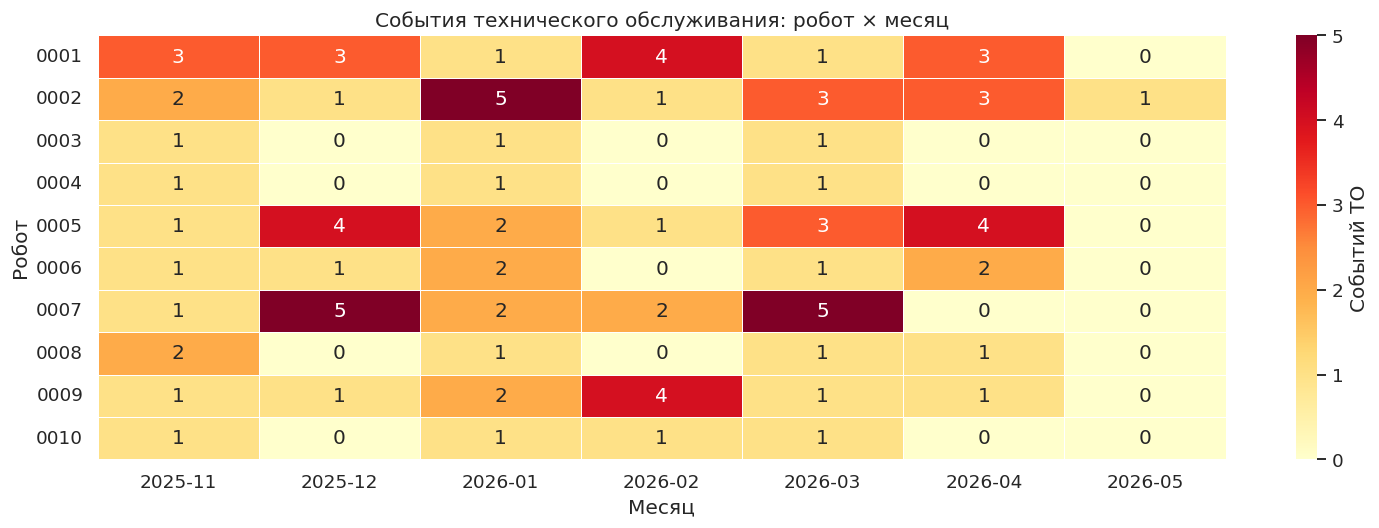

In [6]:
# Тепловая карта: события ТО по роботу и месяцу
maint['month'] = maint['completed_at'].dt.to_period('M').astype(str)
heat = maint.groupby(['robot_id', 'month']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(heat, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5,
            ax=ax, cbar_kws={'label': 'Событий ТО'})
ax.set_title('События технического обслуживания: робот × месяц')
ax.set_xlabel('Месяц')
ax.set_ylabel('Робот')
plt.tight_layout()
plt.show()

---
## 3. Миссии уборки

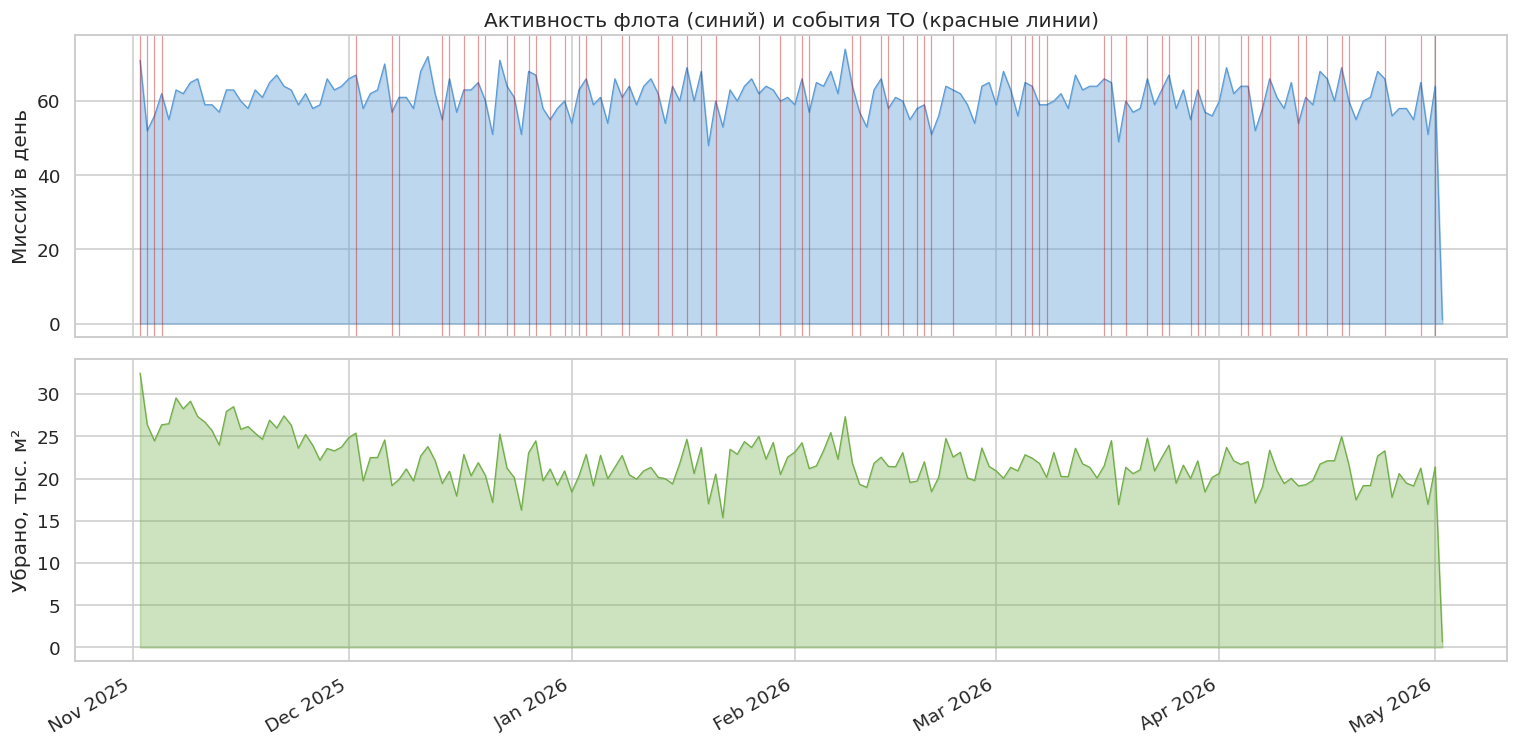

In [7]:
# Ежедневная активность флота + наложение событий ТО
tasks['dt'] = pd.to_datetime(tasks['start_time']).dt.date
daily = tasks.groupby('dt').agg(
    missions=('report_id', 'count'),
    area_m2 =('actual_area_m2', 'sum'),
).reset_index()
daily['dt'] = pd.to_datetime(daily['dt'])

maint_daily = maint.groupby(maint['completed_at'].dt.date).size().reset_index()
maint_daily.columns = ['dt', 'maint_count']
maint_daily['dt'] = pd.to_datetime(maint_daily['dt'])

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].fill_between(daily['dt'], daily['missions'], alpha=0.4, color='#5B9BD5')
axes[0].plot(daily['dt'], daily['missions'], color='#5B9BD5', linewidth=0.8)
for _, row in maint_daily.iterrows():
    axes[0].axvline(row['dt'], color='#C00000', alpha=0.4, linewidth=0.8)
axes[0].set_ylabel('Миссий в день')
axes[0].set_title('Активность флота (синий) и события ТО (красные линии)')

axes[1].fill_between(daily['dt'], daily['area_m2'] / 1000, alpha=0.35, color='#70AD47')
axes[1].plot(daily['dt'], daily['area_m2'] / 1000, color='#70AD47', linewidth=0.8)
axes[1].set_ylabel('Убрано, тыс. м²')
axes[1].set_xlabel('')

axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[1].xaxis.set_major_locator(mdates.MonthLocator())
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

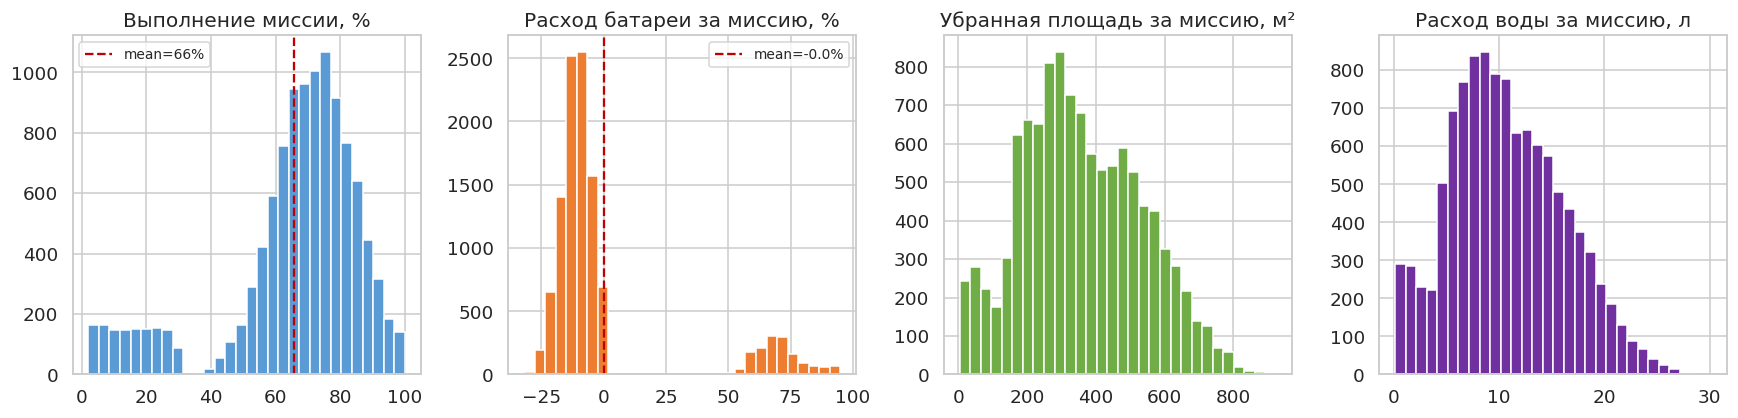

completion_percentage:  min=0.02  median=0.70  max=1.00
battery_delta_pct:      min=-32  median=-9  max=95


In [8]:
# Распределения ключевых метрик миссий
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].hist(tasks['completion_percentage'] * 100, bins=30,
             color='#5B9BD5', edgecolor='white')
axes[0].axvline(tasks['completion_percentage'].mean() * 100,
                color='#C00000', linestyle='--', label=f'mean={tasks["completion_percentage"].mean()*100:.0f}%')
axes[0].set_title('Выполнение миссии, %')
axes[0].legend(fontsize=9)

axes[1].hist(tasks['battery_delta_pct'], bins=30,
             color='#ED7D31', edgecolor='white')
axes[1].axvline(tasks['battery_delta_pct'].mean(), color='#C00000', linestyle='--',
                label=f'mean={tasks["battery_delta_pct"].mean():.1f}%')
axes[1].set_title('Расход батареи за миссию, %')
axes[1].legend(fontsize=9)

axes[2].hist(tasks['actual_area_m2'], bins=30,
             color='#70AD47', edgecolor='white')
axes[2].set_title('Убранная площадь за миссию, м²')

axes[3].hist(tasks['water_consumption_l'], bins=30,
             color='#7030A0', edgecolor='white')
axes[3].set_title('Расход воды за миссию, л')

plt.tight_layout()
plt.show()

print(f'completion_percentage:  min={tasks["completion_percentage"].min():.2f}  '
      f'median={tasks["completion_percentage"].median():.2f}  '
      f'max={tasks["completion_percentage"].max():.2f}')
print(f'battery_delta_pct:      min={tasks["battery_delta_pct"].min()}  '
      f'median={tasks["battery_delta_pct"].median():.0f}  '
      f'max={tasks["battery_delta_pct"].max()}')

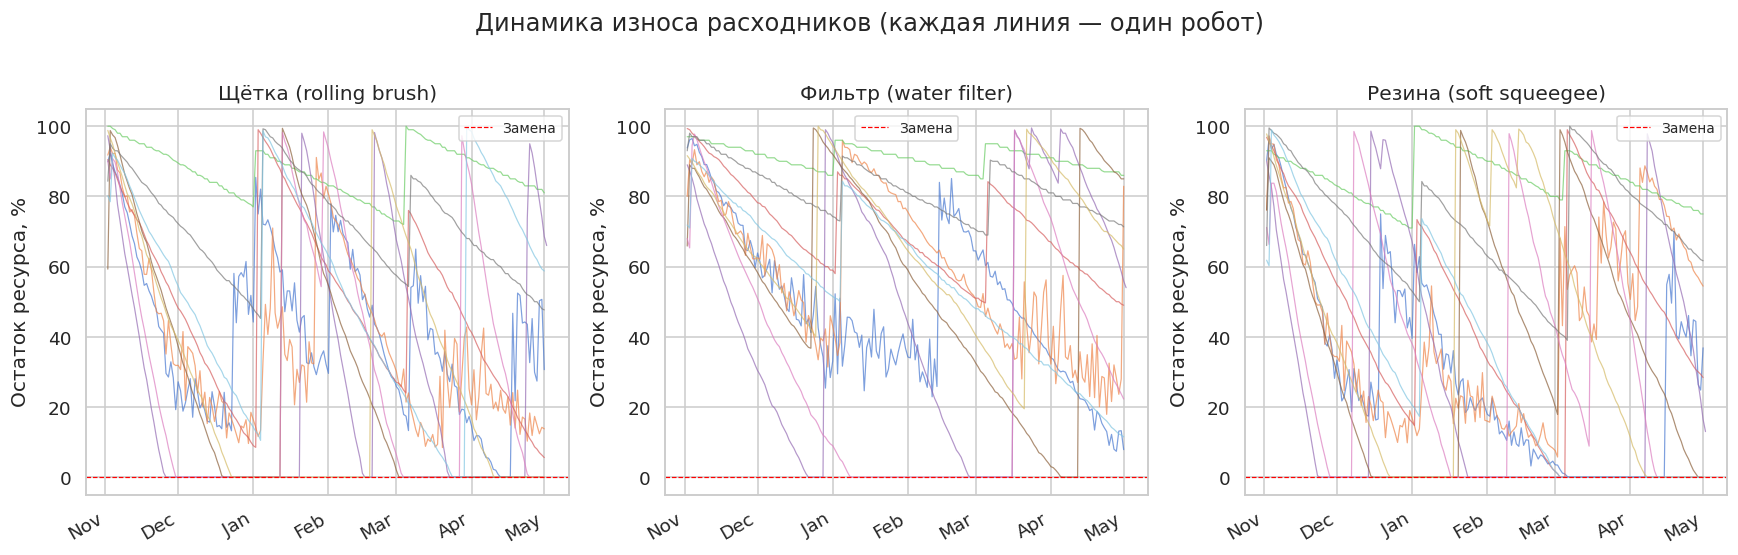

In [9]:
# Прогрессия износа расходников во времени (по всем роботам)
# Берём последний опрос каждого робота в каждый день (из task_reports consumables)
wear = tasks[['start_time', 'robot_id', 'brush_residual_pct',
              'filter_residual_pct', 'suction_blade_residual_pct']].copy()
wear['date'] = pd.to_datetime(wear['start_time']).dt.date

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

consumables = [
    ('brush_residual_pct',        'Щётка (rolling brush)',   '#ED7D31'),
    ('filter_residual_pct',       'Фильтр (water filter)',   '#5B9BD5'),
    ('suction_blade_residual_pct','Резина (soft squeegee)',  '#70AD47'),
]

for ax, (col, title, color) in zip(axes, consumables):
    for robot, grp in wear.groupby('robot_id'):
        daily_wear = grp.groupby('date')[col].mean().reset_index()
        daily_wear['date'] = pd.to_datetime(daily_wear['date'])
        ax.plot(daily_wear['date'], daily_wear[col], linewidth=0.8, alpha=0.7)
    ax.axhline(0, color='red', linestyle='--', linewidth=0.8, label='Замена')
    ax.set_title(title)
    ax.set_ylabel('Остаток ресурса, %')
    ax.set_ylim(-5, 105)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.legend(fontsize=9)

fig.autofmt_xdate()
plt.suptitle('Динамика износа расходников (каждая линия — один робот)', y=1.01)
plt.tight_layout()
plt.show()

---
## 4. Статус роботов

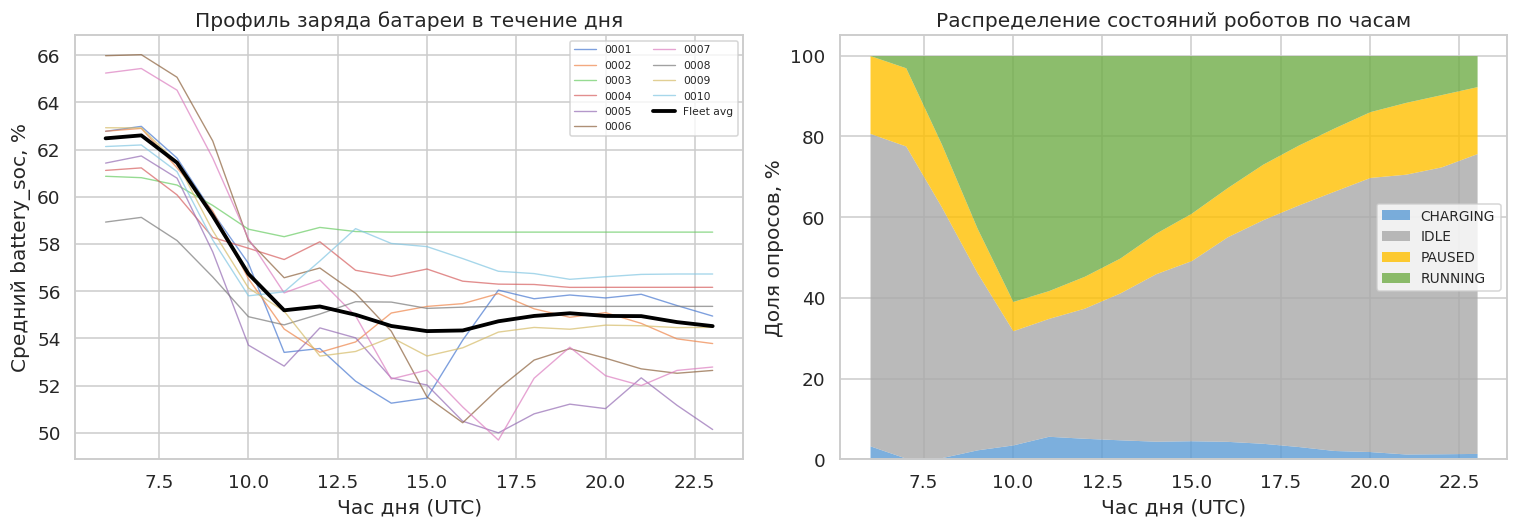

In [10]:
# Внутридневной профиль заряда батареи
status['hour'] = status['poll_ts'].dt.hour

# Средний SOC по часу (среднее по всем роботам и дням)
hourly = status.groupby(['robot_id', 'hour'])['battery_soc'].mean().reset_index()
hourly_fleet = status.groupby('hour')['battery_soc'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for robot, grp in hourly.groupby('robot_id'):
    axes[0].plot(grp['hour'], grp['battery_soc'], linewidth=0.9, alpha=0.7, label=robot)
axes[0].plot(hourly_fleet.index, hourly_fleet.values,
             color='black', linewidth=2.5, label='Fleet avg', zorder=5)
axes[0].set_xlabel('Час дня (UTC)')
axes[0].set_ylabel('Средний battery_soc, %')
axes[0].set_title('Профиль заряда батареи в течение дня')
axes[0].legend(fontsize=7, ncol=2)

# Task state distribution by hour
ts_hour = (status.groupby(['hour', 'task_state'])
           .size().unstack(fill_value=0))
ts_pct = ts_hour.div(ts_hour.sum(axis=1), axis=0) * 100
state_colors = {'RUNNING': '#70AD47', 'CHARGING': '#5B9BD5',
                'IDLE': '#A9A9A9', 'PAUSED': '#FFC000'}
ts_pct[[c for c in ts_pct.columns if c in state_colors]].plot.area(
    ax=axes[1], color=[state_colors[c] for c in ts_pct.columns if c in state_colors],
    linewidth=0, alpha=0.8)
axes[1].set_xlabel('Час дня (UTC)')
axes[1].set_ylabel('Доля опросов, %')
axes[1].set_title('Распределение состояний роботов по часам')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

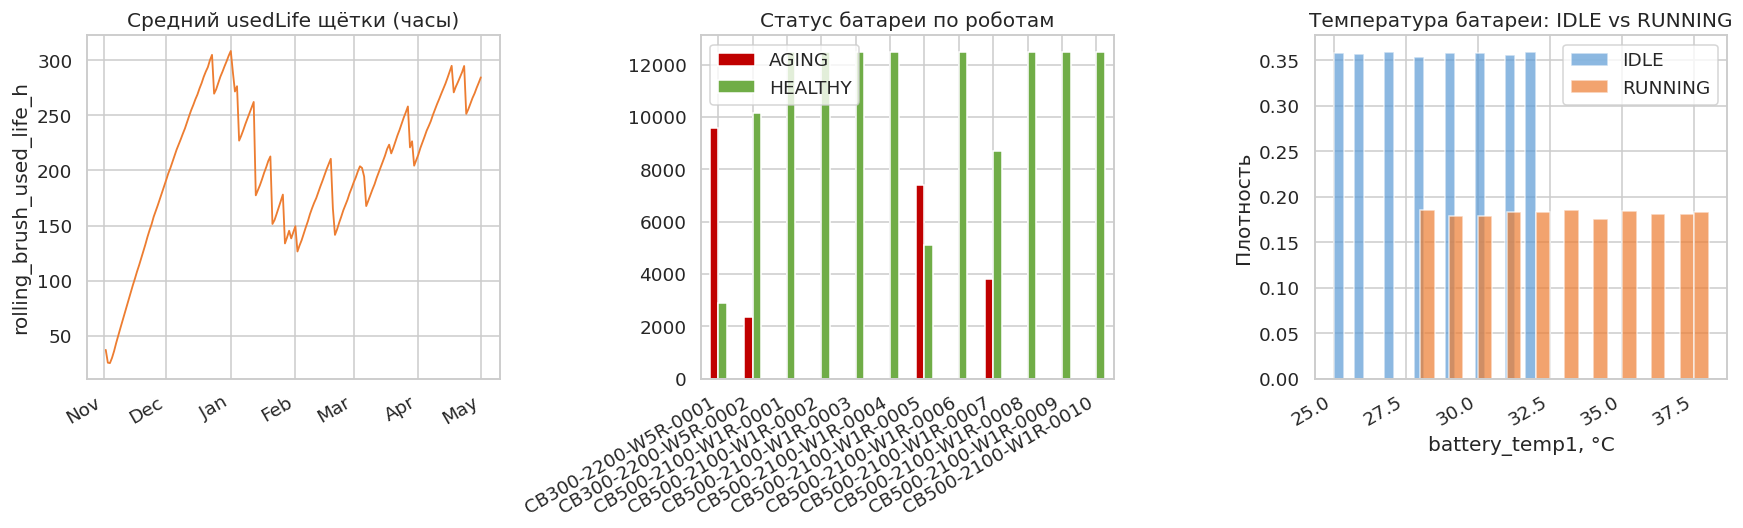

In [11]:
# Прогрессия износа расходников из robot_status + здоровье батареи
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Rolling brush wear over time from status
daily_brush = status.groupby('dt')['rolling_brush_used_life_h'].mean().reset_index()
daily_brush['dt'] = pd.to_datetime(daily_brush['dt'])
axes[0].plot(daily_brush['dt'], daily_brush['rolling_brush_used_life_h'],
             color='#ED7D31', linewidth=1.2)
axes[0].set_title('Средний usedLife щётки (часы)')
axes[0].set_ylabel('rolling_brush_used_life_h')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b'))
axes[0].xaxis.set_major_locator(mdates.MonthLocator())

# Battery health distribution
bh = status.groupby(['serial_number', 'battery_health']).size().unstack(fill_value=0)
bh.plot.bar(ax=axes[1], color=['#C00000', '#70AD47'], edgecolor='white')
axes[1].set_title('Статус батареи по роботам')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(['AGING', 'HEALTHY'])

# Battery temperature distribution during RUNNING vs IDLE
running_temp = status.loc[status['task_state'] == 'RUNNING', 'battery_temp1']
idle_temp    = status.loc[status['task_state'] == 'IDLE',    'battery_temp1']
axes[2].hist(idle_temp,    bins=20, alpha=0.7, color='#5B9BD5', label='IDLE',    density=True)
axes[2].hist(running_temp, bins=20, alpha=0.7, color='#ED7D31', label='RUNNING', density=True)
axes[2].set_title('Температура батареи: IDLE vs RUNNING')
axes[2].set_xlabel('battery_temp1, °C')
axes[2].set_ylabel('Плотность')
axes[2].legend()

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

---
## 5. Связь источников: эксплуатация и техническое обслуживание

Ключевой вопрос: **отражает ли интенсивность эксплуатации вероятность события ТО?**  
Это необходимое условие для построения признаков предиктивной модели.

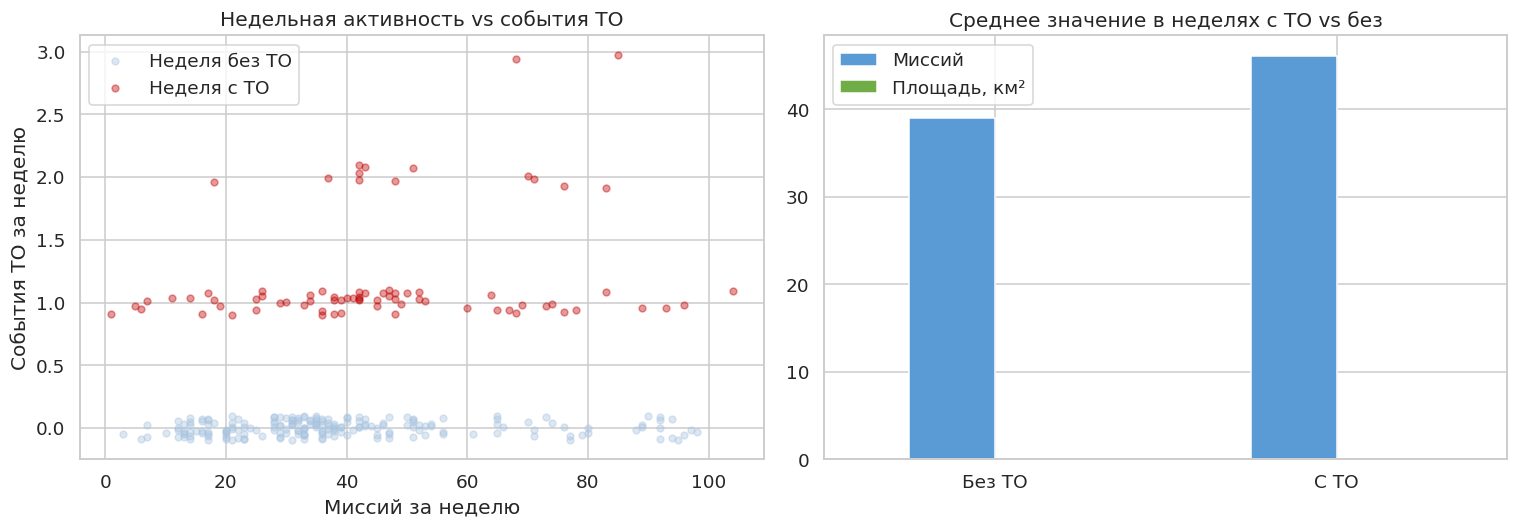

Корреляция (missions, maint_events):  0.182
Корреляция (area_m2,  maint_events):  0.221


In [12]:
# Эксплуатация vs события ТО: агрегация по роботу и неделе
tasks['week'] = pd.to_datetime(tasks['start_time']).dt.to_period('W').astype(str)
maint['week'] = pd.to_datetime(maint['completed_at']).dt.to_period('W').astype(str)

weekly_usage = tasks.groupby(['robot_id', 'week']).agg(
    missions = ('report_id', 'count'),
    area_m2  = ('actual_area_m2', 'sum'),
).reset_index()

weekly_maint = maint.groupby(['robot_id', 'week']).size().reset_index(name='maint_events')

weekly = weekly_usage.merge(weekly_maint, on=['robot_id', 'week'], how='left')
weekly['maint_events'] = weekly['maint_events'].fillna(0)
weekly['has_maint'] = weekly['maint_events'] > 0

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: missions per week vs maintenance events
for has_m, grp in weekly.groupby('has_maint'):
    color = '#C00000' if has_m else '#A9C4E0'
    label = 'Неделя с ТО' if has_m else 'Неделя без ТО'
    axes[0].scatter(grp['missions'], grp['maint_events'] + np.random.uniform(-0.1, 0.1, len(grp)),
                    alpha=0.4, s=20, color=color, label=label)
axes[0].set_xlabel('Миссий за неделю')
axes[0].set_ylabel('События ТО за неделю')
axes[0].set_title('Недельная активность vs события ТО')
axes[0].legend()

# Среднее число миссий на неделях с ТО и без
means = weekly.groupby('has_maint')[['missions', 'area_m2']].mean()
means.index = ['Без ТО', 'С ТО']
means['area_km2'] = means['area_m2'] / 1e6
means[['missions', 'area_km2']].plot.bar(ax=axes[1],
                                          color=['#5B9BD5', '#70AD47'],
                                          edgecolor='white')
axes[1].set_title('Среднее значение в неделях с ТО vs без')
axes[1].set_xticklabels(['Без ТО', 'С ТО'], rotation=0)
axes[1].legend(['Миссий', 'Площадь, км²'])

plt.tight_layout()
plt.show()

# Корреляция
corr_missions = weekly['missions'].corr(weekly['maint_events'])
corr_area     = weekly['area_m2'].corr(weekly['maint_events'])
print(f'Корреляция (missions, maint_events):  {corr_missions:.3f}')
print(f'Корреляция (area_m2,  maint_events):  {corr_area:.3f}')

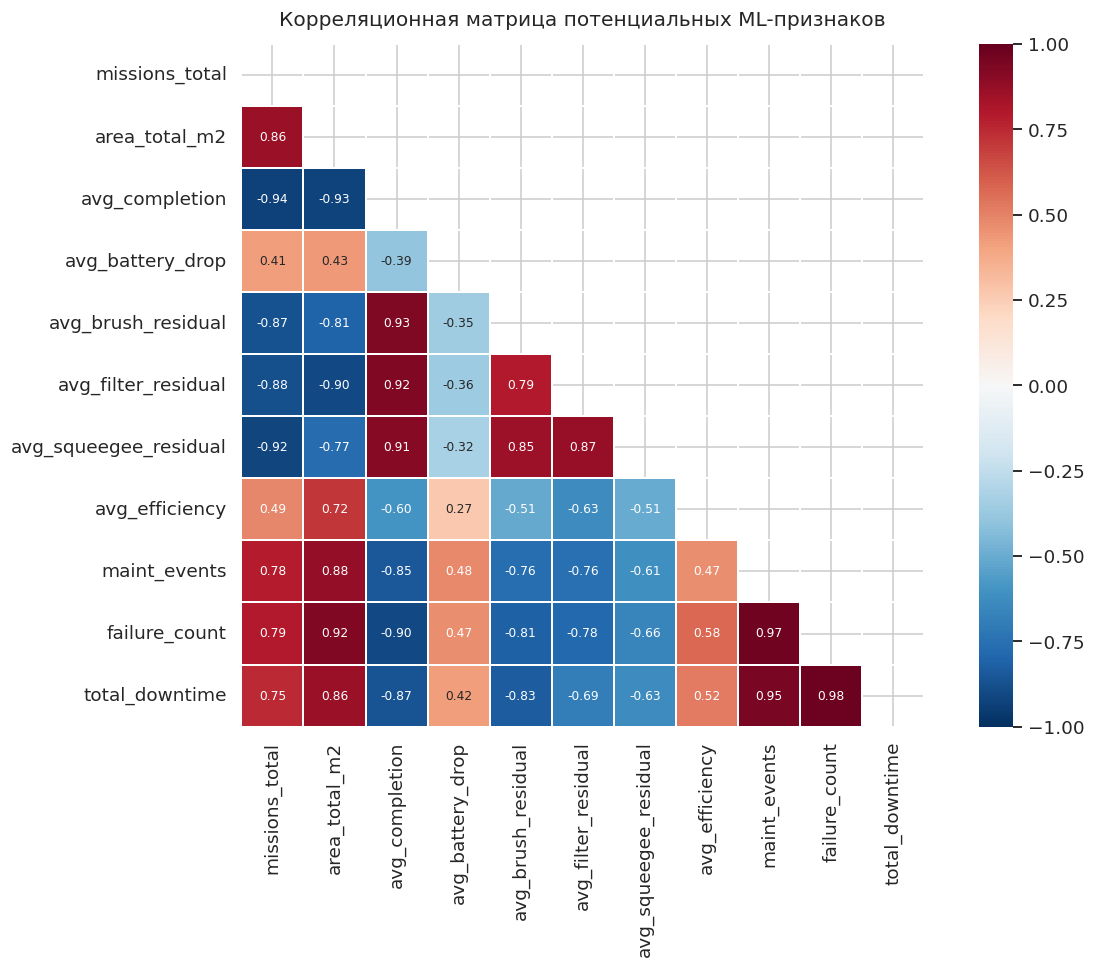


Топ корреляций с failure_count:
total_downtime           0.982178
maint_events             0.970150
area_total_m2            0.923962
avg_completion          -0.898792
avg_brush_residual      -0.814376
missions_total           0.794116
avg_filter_residual     -0.781818
avg_squeegee_residual   -0.664016
avg_efficiency           0.576791
avg_battery_drop         0.468023


In [13]:
# Корреляционная матрица потенциальных ML-признаков
# Для каждого робота считаем 30-дневные агрегаты + метрики состояния

robot_features = tasks.groupby('robot_serial_number').agg(
    missions_total        = ('report_id',              'count'),
    area_total_m2         = ('actual_area_m2',         'sum'),
    avg_completion        = ('completion_percentage',  'mean'),
    avg_battery_drop      = ('battery_delta_pct',      'mean'),
    avg_brush_residual    = ('brush_residual_pct',     'mean'),
    avg_filter_residual   = ('filter_residual_pct',    'mean'),
    avg_squeegee_residual = ('suction_blade_residual_pct', 'mean'),
    avg_efficiency        = ('efficiency_m2_per_hour', 'mean'),
    avg_water             = ('water_consumption_l',    'mean'),
).reset_index()

maint_per_robot = maint.groupby('robot_id_full').agg(
    maint_events   = ('maintenance_id', 'count'),
    failure_count  = ('failure_detected', 'sum'),
    total_downtime = ('downtime_minutes', 'sum'),
).reset_index().rename(columns={'robot_id_full': 'robot_serial_number'})

features = robot_features.merge(maint_per_robot, on='robot_serial_number', how='left')
features['failure_count']  = features['failure_count'].fillna(0)
features['total_downtime'] = features['total_downtime'].fillna(0)
features['maint_events']   = features['maint_events'].fillna(0)

feat_cols = [
    'missions_total', 'area_total_m2', 'avg_completion', 'avg_battery_drop',
    'avg_brush_residual', 'avg_filter_residual', 'avg_squeegee_residual',
    'avg_efficiency', 'maint_events', 'failure_count', 'total_downtime',
]
corr_matrix = features[feat_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, mask=mask, ax=ax,
            linewidths=0.3, square=True, vmin=-1, vmax=1,
            annot_kws={'size': 8})
ax.set_title('Корреляционная матрица потенциальных ML-признаков', pad=12)
plt.tight_layout()
plt.show()

# Топ корреляций с целевой переменной (failure_count)
print('\nТоп корреляций с failure_count:')
target_corr = corr_matrix['failure_count'].drop('failure_count').sort_values(key=abs, ascending=False)
print(target_corr.to_string())

---
## 6. Выводы

### 6.1 Характеристика датасета

За 181 день зафиксировано **11 095 миссий уборки**, **93 события ТО** и **149 868 опросов статуса** по 12 роботам двух моделей (CleanBot W1 и W50H). Данные покрывают весь жизненный цикл расходников (усреднённый износ щётки по флоту варьируется от 44 до 614 ч при номинальном ресурсе 300 ч), что обеспечивает достаточное разнообразие состояний для обучения предиктивной модели.

Нагрузка по флоту распределена неравномерно: лидеры (CB500-0005, CB500-0007, CB300-0001) выполняют 1 200–1 300 миссий за период, аутсайдеры — менее 700. Это подчёркивает необходимость нормировать признаки на робота, а не усреднять по флоту.

---

### 6.2 Структура событий технического обслуживания

**65% событий ТО — корректирующие** (реактивный ремонт после отказа), 24% — плановые профилактические, 11% — диагностические осмотры. Преобладание корректирующего ТО подтверждает экономическую мотивацию задачи: реактивная стратегия ведёт к незапланированным простоям.

Средний простой при корректирующем ТО составляет **239 минут (~4 часа)** — против ~130 минут при плановом. Накопленный суммарный простой по флоту за период превышает 17 000 минут (~12 рабочих дней).

Наиболее уязвимые компоненты — **щётка и резина (suction_blade)** по 24 события каждый, затем фильтр (17). Именно эти три компонента обеспечивают 70% всех событий ТО и должны быть в центре feature engineering.

**65% событий сопровождаются подтверждённым отказом**, причём все critical и high события — отказы по определению. Это означает, что поле `failure_detected` пригодно как основа для бинарной целевой переменной `has_failure_next_30d`.

---

### 6.3 Влияние износа на качество уборки

Обнаружен статистически значимый эффект износа на операционные метрики:

| Состояние щётки | Avg completion |
|---|---|
| brush_residual ≥ 20% (норма) | **71.0%** |
| brush_residual < 20% (критический износ) | **56.8%** |

Разница в **14.2 п.п.** означает, что изношенный робот в среднем убирает на 14% меньше площади за ту же миссию. Этот эффект видим в данных и может быть использован как косвенный признак надвигающегося отказа ещё до самого события ТО.

Медианный процент выполнения миссии по флоту составляет **70%** при теоретическом максимуме 100%, что указывает на систематически незавершаемые миссии — вероятно, связанные с разрядом батареи или ошибками навигации.

---

### 6.4 Операционные паттерны и батарея

Роботы активны с 7:00 до 16:00 UTC (пик задач типа RUNNING), после чего переходят в режим ожидания. Распределение состояний:

- **IDLE: 53.9%** — роботы большую часть времени простаивают
- **RUNNING: 29.6%** — активная уборка
- **PAUSED: 13.3%** — промежуточные паузы
- **CHARGING: 3.1%** — зарядка

Средний уровень заряда к концу рабочего дня снижается с 62% (6:00) до 54% (16:00–23:00) и остаётся стабильным — роботы не полностью разряжаются за смену.

Температура батареи при работе (**33°C** vs **28.5°C** в покое) остаётся в допустимом диапазоне, однако у роботов со статусом AGING (15.4% всех опросов, сконцентрированы на конкретных машинах) тепловые характеристики могут деградировать быстрее.

---

### 6.5 Корреляционный анализ: сигналы для предиктивной модели

Корреляционная матрица на уровне робота выявила сильные связи с целевой переменной `failure_count`:

| Признак | r с failure_count | Интерпретация |
|---|---|---|
| `total_downtime` | **+0.98** | следствие (не признак) |
| `maint_events` | **+0.97** | следствие (не признак) |
| `area_total_m2` | **+0.92** | ключевой предиктор: больше уборки → больше износа |
| `avg_completion` | **−0.90** | снижение completion сигнализирует об износе |
| `avg_brush_residual` | **−0.81** | прямой индикатор износа щётки |
| `missions_total` | **+0.79** | интенсивность эксплуатации |
| `avg_filter_residual` | **−0.78** | прямой индикатор износа фильтра |
| `avg_squeegee_residual` | **−0.66** | индикатор износа резины |
| `avg_efficiency` | **+0.58** | более нагруженные объекты имеют больше отказов |

`total_downtime` и `maint_events` — следствия отказов, а не признаки; они должны быть исключены из feature set для предотвращения target leakage. Реальными предикторами являются метрики износа и интенсивности эксплуатации.

Слабая недельная корреляция (r ≈ 0.18–0.22) при сильной межроботной (r ≈ 0.79–0.92) указывает на то, что риск накапливается на горизонте недель–месяцев, а не дней. Это подтверждает обоснованность целевого горизонта **30 дней** для предиктивной модели.

---

### 6.6 Пригодность данных для обучения ML-модели

Данные демонстрируют три необходимых условия для предиктивного обслуживания:

1. **Наблюдаемые сигналы**: износ расходников напрямую измерим через `usedLife` в `robot_status` и `*_residual_pct` в `task_reports`.
2. **Причинно-следственная связь**: интенсивность эксплуатации (площадь, миссии) предшествует событиям ТО и коррелирует с ними (r ≈ 0.79–0.92).
3. **Достаточная вариативность**: широкий разброс износа по роботам (44–614 ч при ресурсе 300 ч) обеспечивает разнообразные состояния в обучающей выборке.

**Рекомендуемый feature set** для Gold-слоя (признаки на дату `feature_date`):
- `days_since_last_maintenance`, `days_since_last_failure`
- `missions_count_30d`, `area_cleaned_30d`, `avg_completion_30d`
- `brush_residual_last`, `filter_residual_last`, `squeegee_residual_last`
- `battery_cycle_times`, `battery_health`
- `failure_count_90d`, `downtime_minutes_30d`

**Ограничение датасета**: 93 события ТО на 12 роботов дают лишь ~8 событий на робота за 181 день, что является минимально допустимым для обучения. В реальном производственном сценарии потребуется расширение истории до 12–24 месяцев или увеличение флота.